In [1]:
import os
import pandas as pd 
import numpy as np
import argparse
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.stats import pearsonr
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (6/2.54, 6/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")



In [6]:

eid = 'E118'
gene_id2neighbors=f'extra/datasets/processed/v1/{eid}/gene_id2neighbors_{eid}.csv'


EIDS_TO_CELLTYPES = {
    'E116':'gm12878',
    'E118':'HepG2',
    'E003':'H1'
}

MEAN_THRESHOLD = 20
BS_THRESHOLD = 20
BF_THRESHOLD = 100

# TARGET_INDICATOR = 'cv'

kinetics = pd.read_csv(f'extra/datasets/burst/processed/{EIDS_TO_CELLTYPES[eid]}_statistic_gene_transcript_region.csv')
bulk_exp = pd.read_csv('extra/datasets/annotations/exp_raw.tsv',sep='\t')[['gene_id',eid]]
bulk_exp.columns = ['gene_id','bulk_exp']
gene_id2neighbors = pd.read_csv(gene_id2neighbors, names=['gene_id','eid','chrom','start','end','strand','neighbors','scores'])

meta_data = pd.merge(gene_id2neighbors,kinetics, how='inner', on='gene_id')
meta_data = pd.merge(meta_data,bulk_exp, how='inner', on='gene_id')


# BS=mu/beta；
# BF=(alpha*beta)/(alpha+beta)
# meta_data['bf'] = 1/(1/meta_data['k_on']+1/meta_data['k_off'])
meta_data['mean'] = meta_data['bf']*meta_data['bs']
# meta_data['mean'] = meta_data['k_on']*meta_data['k_syn']/(meta_data['k_on']+meta_data['k_off'])
meta_data['cv_1'] = meta_data.apply(lambda row: 0 if row['mean'] < 0.0001 else 1/row['mean'] + row['k_off']/row['k_on'] - ((row['k_on'] + row['k_off'])/row['k_on'] )*(1-(row['k_on']/(1+row['k_on'])))/((1+row['k_off'])/row['k_off'] - row['k_on']/(1+row['k_on'])),axis=1)

# meta_data['cv'] = meta_data.apply(lambda row: 0 if row['mean'] < 0.0001 else 1/row['mean'] + row['k_off']/row['k_on'] - ((row['k_on'] + row['k_off'])/row['k_on'] )*(1-(row['k_on']/(1+row['k_on'])))/((1+row['k_off'])/row['k_off'] - row['k_on']/(1+row['k_on'])),axis=1)



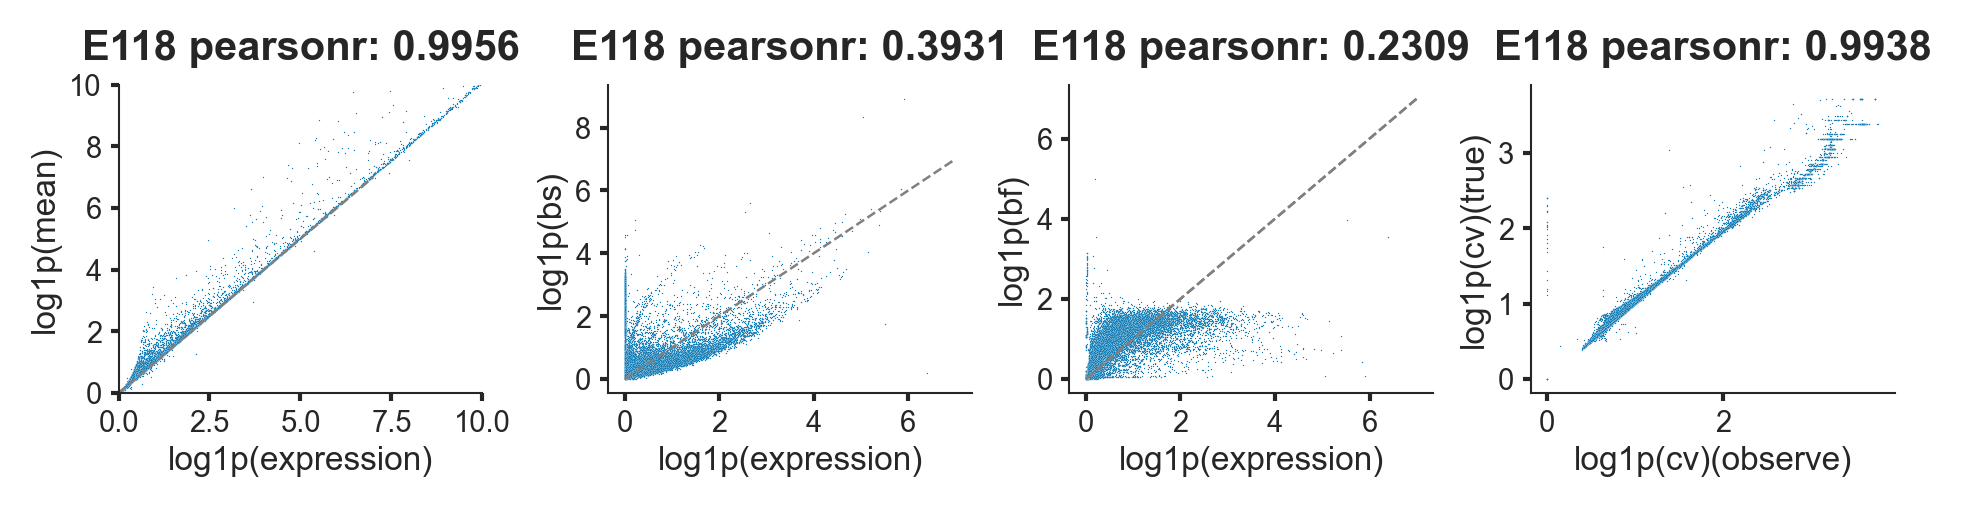

In [8]:
fig, ax = plt.subplots(1, 4, constrained_layout=True, figsize=(16/2.54, 4/2.54))

# sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['mean']),s=0.1,ax=ax[0])
sns.scatterplot(x=(meta_data['expression']),y=(meta_data['mean']),s=0.1,ax=ax[0])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[0])
# corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['mean']))
corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['mean']))
ax[0].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[0].set_xlabel('log1p(expression)')
ax[0].set_ylabel('log1p(mean)')
ax[0].set_ylim(0,10)
ax[0].set_xlim(0,10)


sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['bs']),s=0.1,ax=ax[1])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[1])
# corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['bs']))
corr_pearson, _ = pearsonr((meta_data['expression']), (meta_data['bs']))
# corr_pearson, _ = pearsonr(meta_data['expression'], (meta_data['bs']))
ax[1].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[1].set_xlabel('log1p(expression)')
ax[1].set_ylabel('log1p(bs)')


sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['bf']),s=0.1,ax=ax[2])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[2])
corr_pearson, _ = pearsonr((meta_data['expression']), (meta_data['bf']))
ax[2].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[2].set_xlabel('log1p(expression)')
ax[2].set_ylabel('log1p(bf)')

sns.scatterplot(x=np.log1p(np.sqrt(meta_data['cv_1'])),y=np.log1p((meta_data['cv'])),s=0.1,ax=ax[3])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[2])
corr_pearson, _ = pearsonr(np.log1p(np.sqrt(meta_data['cv_1'])), np.log1p(meta_data['cv']))
ax[3].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[3].set_xlabel('log1p(cv)(observe)')
ax[3].set_ylabel('log1p(cv)(true)')

plt.show()


In [39]:
bulk_exp_median =  np.median(meta_data['bulk_exp'])
mean_median = np.median(meta_data['mean'])
sc_exp_median = np.median(meta_data['expression'])

meta_data['bulk_exp_label'] = meta_data['bulk_exp'] > bulk_exp_median
meta_data['bulk_exp_label'] = np.int32(meta_data['bulk_exp_label'])

meta_data['mean_label'] = meta_data['mean'] > mean_median
meta_data['mean_label'] = np.int32(meta_data['mean_label'])

meta_data['sc_exp_label'] = meta_data['expression'] > sc_exp_median
meta_data['sc_exp_label'] = np.int32(meta_data['sc_exp_label'])

meta_data = meta_data[meta_data['mean_label'] == meta_data['bulk_exp_label']]

bs_median = np.median(meta_data['bs'])
bf_median = np.median(meta_data['bf'])
cv_median = np.median(meta_data['cv'])
# mean_median = np.median(meta_data['mean'])

meta_data['bs_label'] = meta_data.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
meta_data['bf_label'] = meta_data.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)
meta_data['cv_label'] = meta_data.apply(lambda row: 1 if row['cv'] > cv_median else 0, axis=1)
# meta_data['mean_label'] = meta_data.apply(lambda row: 1 if row['cv'] > mean_median else 0, axis=1)


In [40]:
meta_data
# meta_data_1[meta_data_1['sc_exp_label']==meta_data_1['mean_label']].describe()

,gene_id,eid,chrom,start,end,strand,neighbors,scores,expression,variance,...,k_syn,gene_name,bulk_exp,mean,bulk_exp_label,mean_label,sc_exp_label,bs_label,bf_label,cv_label
0,ENSG00000122417,E003,chr1,86862006,86862007,-,NaN,NaN,7.062315,152.070301,...,309.023993,ODF2L,5.509,7.626420,1,1,1,1,1,0
1,ENSG00000143320,E003,chr1,156675608,156675609,-,NaN,NaN,18.121662,597.976296,...,3035.783367,CRABP2,95.541,18.688951,1,1,1,1,1,0
2,ENSG00000143319,E003,chr1,156698231,156698232,-,NaN,NaN,5.456973,126.028564,...,1011.448030,ISG20L2,21.710,5.831277,1,1,1,1,1,0
3,ENSG00000143318,E003,chr1,160160363,160160364,+,NaN,NaN,0.100890,1.621869,...,17.661151,CASQ1,1.428,0.143615,0,0,0,1,0,1
4,ENSG00000143315,E003,chr1,160001780,160001781,-,NaN,NaN,3.931751,93.636292,...,136.474118,PIGM,15.004,4.080165,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17989,ENSG00000012817,E003,chrY,21906825,21906826,-,NaN,NaN,2.459941,36.206852,...,54.757974,KDM5D,4.846,2.641222,1,1,1,0,1,1
17990,ENSG00000187191,E003,chrY,26959639,26959640,-,NaN,NaN,0.000000,0.000000,...,1.000000,DAZ3,0.000,0.000012,0,0,0,0,0,0
17991,ENSG00000178605,E003,chrY,180887,180888,-,NaN,NaN,5.047478,96.490327,...,233.298782,GTPBP6,18.969,5.391179,1,1,1,0,1,0
17992,ENSG00000198692,E003,chrY,22737595,22737596,+,NaN,NaN,10.356083,219.131365,...,885.472501,EIF1AY,5.784,11.287297,1,1,1,0,1,0


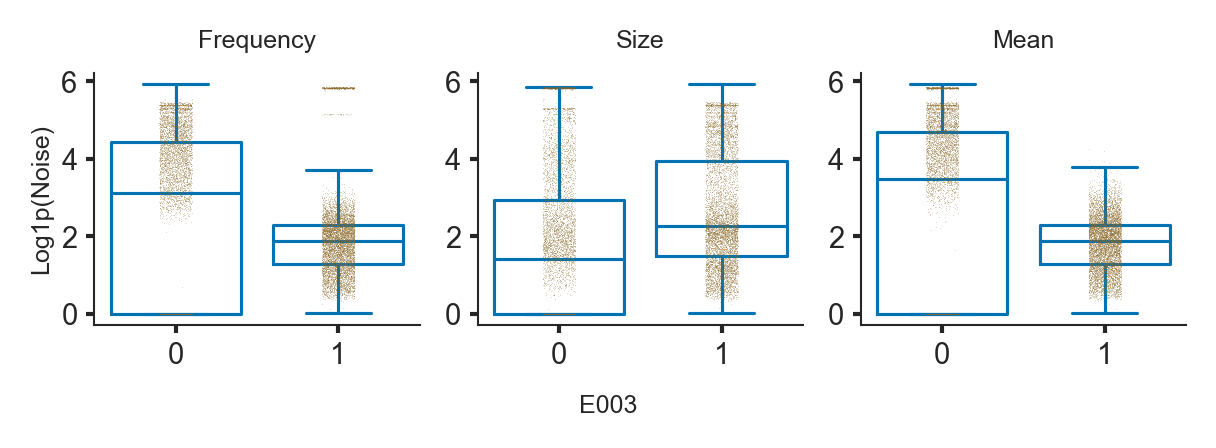

In [41]:
fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))

# Plot without the 'order' parameter
sns.boxplot(x=meta_data['bf_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[0])
sns.stripplot(x=meta_data['bf_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[0])
ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('Log1p(Noise)',fontsize=6)
ax[0].set_xlabel('')

sns.boxplot(x=meta_data['bs_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[1])
sns.stripplot(x=meta_data['bs_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[1])
ax[1].set_title('Size',fontsize=6,fontweight='regular')
ax[1].set_ylabel('')
ax[1].set_xlabel('')


sns.boxplot(x=meta_data['mean_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[2])
sns.stripplot(x=meta_data['mean_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[2])
ax[2].set_title('Mean',fontsize=6,fontweight='regular')
ax[2].set_ylabel('')
ax[2].set_xlabel('')

fig.supxlabel(f'{eid}',fontsize=6)
# ax.tick_params(axis='both', labelsize=5, width=0.5, labelbottom=False, labelleft=True)
plt.show()

In [30]:
eid='E118'
data1 = pd.read_csv('extra/datasets/burst/processed/HepG2_statistic_gene_transcript_region_delay_1.csv')
data2 = pd.read_csv('extra/datasets/burst/processed/HepG2_statistic_gene_transcript_region_delay_0.4.csv')
gene_id2neighbors=f'extra/datasets/processed/v1/{eid}/gene_id2neighbors_{eid}.csv'
gene_id2neighbors = pd.read_csv(gene_id2neighbors, names=['gene_id','eid','chrom','start','end','strand','neighbors','scores'])


In [38]:
data1

,expression,variance,cv,bs,bf,k_on,k_off,k_syn,gene_name,gene_id
0,0.156020,0.175904,2.688178,0.135616,1.172576,1.172576,127.563501,17.299674,AL627309.1,ENSG00000238009
1,0.189189,0.235706,2.566192,0.506222,0.451034,0.451034,2.284953,1.156693,LINC00115,ENSG00000225880
2,0.733415,1.229915,1.512125,0.597120,1.232620,1.232620,396.700126,236.877491,AL645608.5,ENSG00000242590
3,0.000614,0.000614,40.336088,0.002745,0.223926,0.223926,364.278974,1.000000,AL645608.1,ENSG00000224969
4,0.021499,0.027179,7.668382,0.289866,0.081614,0.081614,122.076316,35.385753,SAMD11,ENSG00000187634
...,...,...,...,...,...,...,...,...,...,...
26747,0.000000,0.000000,0.000000,0.002771,0.001000,0.001000,360.925048,1.000000,ZNF197-AS1,ENSG00000233509
26748,0.000000,0.000000,0.000000,0.002771,0.001000,0.001000,360.925048,1.000000,ZNF560,ENSG00000198028
26749,0.000000,0.000000,0.000000,0.002771,0.001000,0.001000,360.925048,1.000000,ZNF671,ENSG00000083814
26750,0.000000,0.000000,0.000000,0.002771,0.001000,0.001000,360.925048,1.000000,ZNF683,ENSG00000176083


In [36]:
target = 'bf'
data = pd.merge(data1[['gene_id',target]],data2[['gene_id',target]],on='gene_id')
data = pd.merge(data,gene_id2neighbors[['gene_id']],on='gene_id')
data

,gene_id,bf_x,bf_y
0,ENSG00000187634,0.081614,0.041752
1,ENSG00000188976,2.874665,2.859498
2,ENSG00000187961,4.001241,4.638622
3,ENSG00000187583,0.162136,0.157016
4,ENSG00000187642,0.005837,0.005099
...,...,...,...
16753,ENSG00000131849,0.001000,0.001000
16754,ENSG00000198028,0.001000,0.001000
16755,ENSG00000083814,0.001000,0.001000
16756,ENSG00000176083,0.001000,0.001000


Text(0.5, 1.0, 'HepG2')

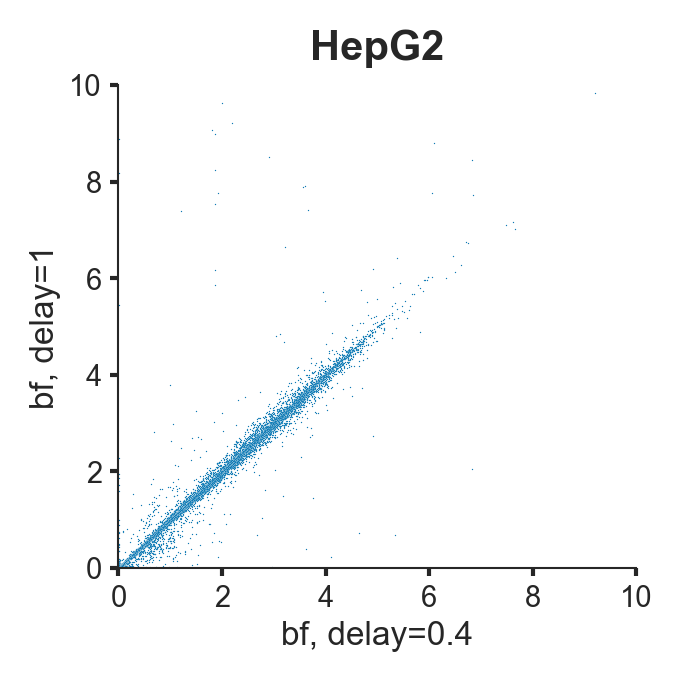

In [37]:

ax = sns.scatterplot(x=(data[f'{target}_x']),y=(data[f'{target}_y']),s=0.1)
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_xlabel(f'{target}, delay=0.4')
ax.set_ylabel(f'{target}, delay=1')
ax.set_title('HepG2')